01_data_preparation_eda.ipynb

Step 1 to Step 8

**STEP 1: BUSINESS UNDERSTANDING**



#### Objective

The objective of this project is to predict whether a customer will churn during a renewal cycle using historical customer interaction data.

#### Problem Statement

The business aims to identify customers who are likely to churn at least 45 days before their renewal date, enabling early intervention strategies.

#### Unit of Analysis

Each row represents:
    1 Customer × 1 Renewal Cycle

#### Target Variable

* Churn = 1 → Customer did not renew
* Churn = 0 → Customer renewed

#### Time Anchor

    Prospect_Renewal_Date


#### Modeling Approach

##### Definition

Only data available before 45 days of the renewal date is used.

##### Time Window

Call_Date <= (Renewal_Date - 45 days)

#### Purpose

* Avoid data leakage
* Mimic real-world prediction
* Enable early churn detection

#### Business Value

Helps the business take proactive retention actions well before renewal.



**STEP 2: Data Understanding**

In this step, we explore all the provided datasets to understand their structure, content, and relationships.

The objectives of this step are:

* To examine dataset dimensions and structure
* To understand column types and meanings
* To identify missing values and inconsistencies
* To detect duplicates
* To identify key columns for joining datasets

The datasets used in this project are:

1. **Billings Dataset** – Contains customer information, renewal details, and target variable
2. **Renewal Calls Dataset** – Contains call interactions during the renewal process
3. **Emails Dataset** – Contains CRM/email interaction signals
4. **Customer Care Calls Dataset** – Contains support and complaint-related interactions

This step helps build a strong understanding of the data before proceeding to cleaning and feature engineering.


In [1]:
!pip install pandas

1. Import libraries

In [2]:
import pandas as pd
import numpy as np

2. Load datasets

In [3]:
billings = pd.read_csv(r"D:\INT230\DS_mini_project\ds_mini-project\Dataset\billings.csv")
renewal_calls = pd.read_csv(r"D:\INT230\DS_mini_project\ds_mini-project\Dataset\renewal_calls.csv")
emails = pd.read_csv(r"D:\INT230\DS_mini_project\ds_mini-project\Dataset\emails.csv")
cc_calls = pd.read_csv(r"D:\INT230\DS_mini_project\ds_mini-project\Dataset\cc_calls.csv")

C:\Users\nehas\AppData\Local\Temp\ipykernel_12764\3282648463.py:1: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  billings = pd.read_csv(r"D:\INT230\DS_mini_project\ds_mini-project\Dataset\billings.csv")
C:\Users\nehas\AppData\Local\Temp\ipykernel_12764\3282648463.py:2: DtypeWarning: Columns (0: Churn_Category, 1: Complaint_Category, 2: Customer_Reaction_Category, 3: Agent_Renewal_Pitch_Category, 4: Customer_Renewal_Response_Category, 5: Agent_Response_Category, 6: Membership_Renewal_Decision, 7: Serious_Complaint, 8: Other_Complaint, 9: Discussion_on_Price_Increase, 10: Renewal_Impact_Due_to_Price_Increase, 11: Discount_or_Waiver_Requested, 12: Call_Reschedule_Request, 13: Agent_Flagged_Membership_Status_Alert, 14: Agent_Renewal_Initiation, 15: Explicit_Competitor_Mention, 16: Explicit_Switching_Intent, 17: Mentioned_Competit

3. Basic inspection function

In [4]:
def inspect(df, name):
    print(f"\n{name} Dataset")
    print("-" * 40)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())

inspect(billings, "Billings")
inspect(renewal_calls, "Renewal Calls")
inspect(emails, "Emails")
inspect(cc_calls, "CC Calls")


Billings Dataset
----------------------------------------
Shape: (122082, 59)

Columns:
['Co_Ref', 'Renewal_Month', 'Connection_Net', 'Connection_Qty', 'Discount_Amount', 'Sustainability_Score', 'Total_Renewal_Score_New', 'Starting_Connection_Net', 'Starting_Connection_Qty', 'Last_Years_Price', 'Last_Years_Date_Paid', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date', 'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe', 'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Renewal_Date', 'Closed_Date', 'Prospect_Status', 'Starting_Net', 'Starting_Vat', 'Starting_Gross', 'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net', 'Gross', 'Membership_Net', 'Package_Net', 'PQQNet',

In [5]:
billings.head()

,Co_Ref,Renewal_Month,Connection_Net,Connection_Qty,Discount_Amount,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,...,Connection_Group,Tenure_Group,#_of_Connection,Last_Renewal,Last_Band,Last_Total_Net_Paid,Last_Connections,Anchor_Group,Renewal_Year,DateTime_Out
0,VT6174,01-11-2024,NaN,NaN,NaN,8.0,42.5,NaN,NaN,799.0,...,1,3,1.0,01-11-2023,Band B,664.0,1.0,1,2024,01-11-2024
1,VD3828,01-08-2025,NaN,NaN,NaN,8.0,41.5,NaN,NaN,799.0,...,1,1,1.0,NaN,NaN,NaN,NaN,1,2025,01-08-2025
2,DV8120,01-03-2025,NaN,NaN,NaN,8.0,33.0,NaN,NaN,799.0,...,1,4+,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025
3,EZ9894,01-06-2025,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,1,4+,1.0,01-06-2024,Band C1,749.0,1.0,1,2025,01-06-2025
4,FA8957,01-03-2025,NaN,NaN,NaN,9.5,42.5,NaN,NaN,799.0,...,1,3,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025


In [6]:
renewal_calls.head()


,Call_ID,Call_Direction,Co_Ref,Call_Date,Churn_Category,Complaint_Category,Customer_Reaction_Category,Agent_Renewal_Pitch_Category,Customer_Renewal_Response_Category,Agent_Response_Category,...,Customer_Response,Desire_To_Cancel,Discount_Offered,Justification_Category,Reason_For_Renewal_Category,Agent_Response_To_Cancel_Category,Argument_That_Convinced_Customer_to_Stay_Category,Analysed_Call,Call_Number,Call_Year
0,5.950000e+11,Outbound,UB0899,29-01-2025,NaN,NaN,Not Mentioned,Discussion / Introduction / Inquiry,Discount and Offer,Discount and Offer,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,3,2025
1,5.970000e+11,OUT_BOUND,HN5141,26-02-2025,NaN,NaN,NaN,Price and Cost,Agreement,Customer Communication,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,2,2025
2,5.950000e+11,Outbound,BP5009,24-01-2025,NaN,NaN,NaN,Expiration / Due,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
3,6.520000e+11,OUT_BOUND,XP8119,09-06-2025,NaN,NaN,NaN,Auto / Automatic,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
4,5.370000e+11,Outbound,ZL7978,20-08-2024,NaN,NaN,NaN,NaN,NaN,NaN,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,28,2024


In [7]:
emails.head()

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,...,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,...,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,...,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,...,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,...,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


In [8]:
cc_calls.head()

,Contact_ID,Call_Date,Direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,...,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,Co_Ref,Analysed_Call,Call_Year
0,6.255130e+11,08-05-2025,OUT_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,30,20,Yes,Yes,No,Yes,Yes,HV3323,1,2025
1,5.910870e+11,25-11-2024,OUT_BOUND,Standard,Yes,No,No,No,Yes,No,...,0,0,Yes,Yes,No,Yes,Yes,PJ7066,1,2024
2,5.650910e+11,23-10-2024,IN_BOUND,Standard,Yes,No,No,No,Yes,No,...,40,20,Yes,Yes,No,Yes,Yes,DP6030,1,2024
3,5.939750e+11,13-01-2025,IN_BOUND,Premier,Yes,No,No,No,Yes,Yes,...,40,30,Yes,Yes,Yes,Yes,Yes,AM2413,1,2025
4,6.222820e+11,19-03-2025,IN_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,40,20,Yes,Yes,No,Yes,Yes,ED6707,1,2025


Unique values

In [9]:
billings['Prospect_Outcome'].value_counts()

Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64

In [10]:
emails['Time_to_Renewal'].value_counts()

Time_to_Renewal
prior_year     40022
14_out         32493
45_out         28008
pre_renewal    22866
Name: count, dtype: int64

Check date columns

In [11]:
billings['Prospect_Renewal_Date'].head()

0    05-11-2024
1    09-08-2025
2    12-03-2025
3    29-06-2025
4    25-03-2025
Name: Prospect_Renewal_Date, dtype: str

In [12]:
renewal_calls['Call_Date'].head()

0    29-01-2025
1    26-02-2025
2    24-01-2025
3    09-06-2025
4    20-08-2024
Name: Call_Date, dtype: str

In [13]:
cc_calls['Call_Date'].head()

0    08-05-2025
1    25-11-2024
2    23-10-2024
3    13-01-2025
4    19-03-2025
Name: Call_Date, dtype: str

### 3. Initial Data Cleaning

In this step, we perform basic data cleaning to prepare the datasets for analysis.

The objectives of this step are:

* To correct data types (especially date columns)
* To remove duplicate records
* To handle obvious missing values
* To standardize categorical values
* To drop irrelevant or junk columns

This step ensures that the data is in a usable format for further analysis and feature engineering.


1. Copy datasets

In [14]:
billings_clean = billings.copy()
renewal_calls_clean = renewal_calls.copy()
emails_clean = emails.copy()
cc_calls_clean = cc_calls.copy()

2. Convert date columns

In [15]:
billings_clean['Prospect_Renewal_Date'] = pd.to_datetime(
    billings_clean['Prospect_Renewal_Date'],
    dayfirst=True,
    errors='coerce'
)

renewal_calls_clean['Call_Date'] = pd.to_datetime(
    renewal_calls_clean['Call_Date'],
    dayfirst=True,
    errors='coerce'
)

cc_calls_clean['Call_Date'] = pd.to_datetime(
    cc_calls_clean['Call_Date'],
    dayfirst=True,
    errors='coerce'
)

3. Remove duplicates

In [16]:
billings_clean = billings_clean.drop_duplicates()
renewal_calls_clean = renewal_calls_clean.drop_duplicates()
emails_clean = emails_clean.drop_duplicates()
cc_calls_clean = cc_calls_clean.drop_duplicates()

4. Drop obvious junk columns

In [17]:
# Example: unnamed columns
renewal_calls_clean = renewal_calls_clean.loc[:, ~renewal_calls_clean.columns.str.contains('^Unnamed')]
cc_calls_clean = cc_calls_clean.loc[:, ~cc_calls_clean.columns.str.contains('^Unnamed')]

5. Standardize text

In [18]:
def clean_text(df):
    for col in df.select_dtypes(include=['object', 'string']).columns:
        df[col] = df[col].apply(
            lambda x: x.strip().lower() if isinstance(x, str) else x
        )
    return df

# Clean target column properly

billings_clean = clean_text(billings_clean)
renewal_calls_clean = clean_text(renewal_calls_clean)
emails_clean = clean_text(emails_clean)
cc_calls_clean = clean_text(cc_calls_clean)

6. Handle obvious missing values

In [19]:
# Drop completely empty columns (all datasets)
billings_clean = billings_clean.dropna(axis=1, how='all')
renewal_calls_clean = renewal_calls_clean.dropna(axis=1, how='all')
emails_clean = emails_clean.dropna(axis=1, how='all')
cc_calls_clean = cc_calls_clean.dropna(axis=1, how='all')


# BILLINGS

# Drop useless column (100% missing)
if 'Last_Years_Date_Paid' in billings_clean.columns:
    billings_clean = billings_clean.drop(columns=['Last_Years_Date_Paid'])

# Drop rows with critical missing values

billings_clean = billings_clean.dropna(
    subset=['Prospect_Outcome','Prospect_Renewal_Date', 'Co_Ref']
)
# RENEWAL CALLS

# Drop rows where Co_Ref is missing (cannot join later)
renewal_calls_clean = renewal_calls_clean.dropna(subset=['Co_Ref'])


# EMAILS

# Drop rows where Co_Ref is missing
emails_clean = emails_clean.dropna(subset=['Co_Ref'])


# CC CALLS

# Drop rows where Call_Date or Co_Ref is missing
cc_calls_clean = cc_calls_clean.dropna(subset=['Call_Date', 'Co_Ref'])


print("After Cleaning:\n")
print("Billings Shape:", billings_clean.shape)
print("Renewal Calls Shape:", renewal_calls_clean.shape)
print("Emails Shape:", emails_clean.shape)
print("CC Calls Shape:", cc_calls_clean.shape)

After Cleaning:

Billings Shape: (122082, 58)
Renewal Calls Shape: (153269, 40)
Emails Shape: (123389, 27)
CC Calls Shape: (31636, 33)


### STEP 4:Target Definition & Cutoff Logic

In this step, we define the target variable (churn) and create a cutoff date to enforce time-based data usage.

1. Check Target Distribution

This step helps us understand the distribution of the target variable (Prospect_Outcome).

It allows us to:

* Identify different outcome categories
* Check class imbalance
* Detect unwanted categories (e.g., "Open")

In [20]:
billings_clean['Prospect_Outcome'].value_counts()

Prospect_Outcome
won        101226
churned     12668
open         8188
Name: count, dtype: int64

2. Remove "Open" Outcomes

Rows with "Open" status are removed because they do not represent a final outcome.

"Won" → Customer renewed
"Churned" → Customer did not renew
"Open" → Outcome not finalized (cannot be used for training)

In [21]:
billings_clean = billings_clean[
    billings_clean['Prospect_Outcome'].isin(['won', 'churned'])
]

3. Create Target Variable (churn)

We convert the categorical outcome into a numerical target variable:

churn = 1 → Customer churned
churn = 0 → Customer renewed

This transformation is required for machine learning models.

In [22]:
billings_clean['churn'] = billings_clean['Prospect_Outcome'].map({
    'won': 0,
    'churned': 1
})

4. Verify Target Variable

This step ensures that the target variable has been created correctly.

It also helps confirm:

Distribution of churn vs non-churn
No unexpected values

In [23]:
billings_clean['churn'].value_counts()

churn
0    101226
1     12668
Name: count, dtype: int64

5. Create Cutoff Date

A cutoff date is created to enforce time-based feature extraction.

Only data available before 45 days of the renewal date is allowed

Formula:
cutoff_date = Prospect_Renewal_Date - 45 days

In [24]:
billings_clean['cutoff_date'] = (
    billings_clean['Prospect_Renewal_Date'] - pd.Timedelta(days=45)
)

6. Validate Cutoff Date

This step verifies that the cutoff date has been calculated correctly.



In [25]:
billings_clean[['Prospect_Renewal_Date', 'cutoff_date']].head()

,Prospect_Renewal_Date,cutoff_date
0,2024-11-05,2024-09-21
1,2025-08-09,2025-06-25
2,2025-03-12,2025-01-26
3,2025-06-29,2025-05-15
4,2025-03-25,2025-02-08


In [26]:
billings_clean.to_csv("billings_clean.csv", index=False)
renewal_calls_clean.to_csv("renewal_calls_clean.csv", index=False)
emails_clean.to_csv("emails_clean.csv", index=False)    
cc_calls_clean.to_csv("cc_calls_clean.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'renewal_calls_clean.csv'

### STEP 5 : Build Modeling Dataset 

In this step, we construct the final modeling dataset by transforming raw interaction data into structured features.

The goal is to:

* Aggregate data at the customer level
* Ensure no data leakage using cutoff_date
* Combine all datasets into a single table

1. Create Base Dataset

We start by copying the cleaned billing dataset.

This dataset acts as the base table because:

* It contains the target variable (churn)
* It defines the unit of analysis (1 customer × 1 renewal)
* All other datasets will be merged onto this

In [ ]:
df = billings_clean.copy()

2. Filter Renewal Calls Using Cutoff Date

We merge renewal calls with the base dataset to bring in the cutoff_date.

Then we filter the data to keep only calls that occurred within:

* 6 months before cutoff_date
* Up to the cutoff_date

This ensures:

* No future data is used
* Only relevant historical data is used


In [ ]:
renewal_calls_filtered = renewal_calls_clean.merge(
    df[['Co_Ref', 'cutoff_date']],
    on='Co_Ref',
    how='inner'
)

renewal_calls_filtered = renewal_calls_filtered[
    (renewal_calls_filtered['Call_Date'] <= renewal_calls_filtered['cutoff_date']) &
    (renewal_calls_filtered['Call_Date'] >= renewal_calls_filtered['cutoff_date'] - pd.Timedelta(days=180))
]

renewal_calls_filtered = renewal_calls_filtered.drop_duplicates(
    subset=['Call_ID', 'cutoff_date']
)

3. Create Renewal Call Features

We aggregate renewal calls at the renewal level.

Grouping is done using:

* Co_Ref
* cutoff_date

This ensures:

* Each renewal is treated separately
* No mixing of multiple renewal cycles

Feature created:

* total_renewal_calls → number of renewal interactions


In [ ]:
renewal_features = renewal_calls_filtered.groupby( ['Co_Ref', 'cutoff_date'] ).agg( total_renewal_calls=('Call_Date', 'count') ).reset_index()

4. Filter Customer Care Calls

We apply the same time filtering logic to customer care calls.

This dataset captures:

* complaints
* issues
* customer dissatisfaction

Only calls within the valid time window are retained.


In [ ]:
cc_calls_filtered = cc_calls_clean.merge(
    df[['Co_Ref', 'cutoff_date']],
    on='Co_Ref',
    how='inner'
)

cc_calls_filtered = cc_calls_filtered[
    (cc_calls_filtered['Call_Date'] <= cc_calls_filtered['cutoff_date']) &
    (cc_calls_filtered['Call_Date'] >= cc_calls_filtered['cutoff_date'] - pd.Timedelta(days=180))
]

5. Create Customer Care Features

We aggregate customer care interactions at the renewal level.

Feature created:

* total_cc_calls → number of support interactions

These features help capture customer dissatisfaction patterns.


In [ ]:
cc_features = cc_calls_filtered.groupby(
    ['Co_Ref', 'cutoff_date']
).agg(
    total_cc_calls=('Call_Date', 'count')
).reset_index()

6. Filter Emails Dataset

The emails dataset is already grouped by time buckets.

We select only relevant buckets:

* prior_year
* 45_out

These represent interactions before the cutoff date.

In [ ]:
emails_filtered = emails_clean[
    emails_clean['Time_to_Renewal'].isin(['prior_year', '45_out'])
]

7. Create Email Features

We aggregate email interactions to create:

* total_emails → number of CRM interactions

This helps capture engagement level of the customer.

In [ ]:
email_features = emails_filtered.groupby('Co_Ref').agg( total_emails=('Time_to_Renewal', 'count') ).reset_index()

8. Merge All Features

We merge all generated features with the base dataset.

Merging is done using:

* Co_Ref
* cutoff_date (for renewal-level alignment)

This ensures:

* No mixing across different renewal cycles


In [ ]:
df = df.merge(renewal_features, on=['Co_Ref', 'cutoff_date'], how='left')
df = df.merge(cc_features, on=['Co_Ref', 'cutoff_date'], how='left')
df = df.merge(email_features, on='Co_Ref', how='left')

9. Handle Missing Values After Merge

After merging, some customers may not have interactions.

We replace missing values with 0:

* No calls → 0
* No emails → 0


In [ ]:
df[['total_renewal_calls', 'total_cc_calls', 'total_emails']] = df[
    ['total_renewal_calls', 'total_cc_calls', 'total_emails']
].fillna(0)

10. Final Dataset Check

We inspect the final dataset to ensure:

* Correct shape
* Features are created properly
* No unexpected issues


In [ ]:
df.head(10)


,Co_Ref,Renewal_Month,Connection_Net,Connection_Qty,Discount_Amount,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,...,Last_Total_Net_Paid,Last_Connections,Anchor_Group,Renewal_Year,DateTime_Out,churn,cutoff_date,total_renewal_calls,total_cc_calls,total_emails
0,vt6174,01-11-2024,NaN,NaN,NaN,8.0,42.5,NaN,NaN,799.0,...,664.0,1.0,1,2024,01-11-2024,0,2024-09-21,0.0,0.0,1.0
1,vd3828,01-08-2025,NaN,NaN,NaN,8.0,41.5,NaN,NaN,799.0,...,NaN,NaN,1,2025,01-08-2025,0,2025-06-25,0.0,0.0,1.0
2,dv8120,01-03-2025,NaN,NaN,NaN,8.0,33.0,NaN,NaN,799.0,...,749.0,1.0,1,2025,01-03-2025,0,2025-01-26,0.0,0.0,0.0
3,ez9894,01-06-2025,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,749.0,1.0,1,2025,01-06-2025,0,2025-05-15,0.0,5.0,2.0
4,fa8957,01-03-2025,NaN,NaN,NaN,9.5,42.5,NaN,NaN,799.0,...,749.0,1.0,1,2025,01-03-2025,0,2025-02-08,0.0,2.0,4.0
5,qs2598,01-06-2025,NaN,NaN,NaN,8.0,40.5,NaN,NaN,799.0,...,749.0,1.0,1,2025,01-06-2025,0,2025-05-08,0.0,0.0,1.0
6,cj9355,01-03-2025,NaN,NaN,NaN,8.0,43.0,NaN,NaN,799.0,...,749.0,1.0,1,2025,01-03-2025,0,2025-01-31,0.0,0.0,2.0
7,fp1608,01-11-2024,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,749.0,1.0,1,2024,01-11-2024,0,2024-09-24,0.0,0.0,2.0
8,tz9717,01-11-2024,NaN,NaN,NaN,8.0,41.0,NaN,NaN,799.0,...,749.0,1.0,1,2024,01-11-2024,0,2024-10-06,0.0,0.0,1.0
9,up7099,01-04-2025,NaN,NaN,NaN,8.0,42.0,NaN,NaN,799.0,...,749.0,3.0,1,2025,01-04-2025,0,2025-02-18,0.0,1.0,2.0


In [ ]:
df.shape

(113894, 63)

In [ ]:
billings_clean.shape

(113894, 60)

### STEP 6 : Basic Feature Creation (Aggregation & Counts)

In this step, we enhance the dataset by creating additional basic features.

Objective:

* Convert raw features into more meaningful signals
* Capture intensity of customer interactions
* Create simple but powerful predictors

These features are derived using:

* Aggregations
* Counts
* Ratios

These will improve model performance and help in better pattern detection during EDA.


1. Interaction Intensity Features

We combine different interaction types to measure overall engagement.

This helps capture:

* How active a customer is
* Total interaction volume



In [ ]:
df['total_interactions'] = (
    df['total_renewal_calls'] +
    df['total_cc_calls'] +
    df['total_emails']
)

2. Ratio Features

We create ratios to understand relative behavior.

This helps normalize data and compare customers better.


In [ ]:
# cc_calls ratio
df['cc_call_ratio'] = df['total_cc_calls'] / (df['total_interactions'] + 1)

# renewal_call ratio
df['renewal_call_ratio'] = df['total_renewal_calls'] / (df['total_interactions'] + 1)

# email ratio
df['email_ratio'] = df['total_emails'] / (df['total_interactions'] + 1)

3. Change-Based Features

We measure how customer values have changed over time.

This helps detect:

* Growth or decline
* Risk patterns


In [ ]:
# connection change
df['connection_change'] = df['Connection_Qty'] - df['Starting_Connection_Qty']

# revenue change
df['revenue_change'] = df['Total_Net_Paid'] - df['Starting_Net']

4. Payment Behavior Features

We analyze payment-related patterns.

This helps capture:

* Customer commitment
* Financial behavior


In [ ]:
# payment ratio

df['payment_ratio'] = df['Total_Amount'] / (df['Amount'] + 1)

5. Tenure-Based Features

We use tenure to understand customer lifecycle.

Longer tenure may indicate:

* Loyalty
* Stability

Even if a tenure score exists, tenure years may still contain missing values that need to be handled carefully.

Tenure score is often a transformed or scaled version and may not fully capture the raw duration information when tenure years are missing.

In this case:

* Tenure score can be used as a proxy where tenure years are missing
* Missing tenure years can be imputed using tenure score patterns or median values
* Retaining tenure years is still useful for interpretability and feature engineering

Both features can complement each other rather than replace one another.


In [ ]:
df['tenure_bucket'] = pd.cut(
    df['Tenure_Years'],
    bins=[0, 1, 3, 5, 10, 50],
    labels=['0-1', '1-3', '3-5', '5-10', '10+']
)

6. Engagement Flags

We convert continuous features into binary indicators.

This helps models capture thresholds easily.


1. High CC Calls Flag

Reason 1: Simplify pattern

Instead of:

0,1,2,3,4,5 calls

We convert to:

LOW(0) vs HIGH(1) based on median

Reason 2: Models love simple signals

Binary features are easier for models to learn

Reason 3: Capture threshold behavior

Example:

Customers with >2 complaints churn more

This feature directly captures that

In [ ]:
df['high_cc_calls'] = (df['total_cc_calls'] > df['total_cc_calls'].median()).astype(int)

2. Low Engagement Flag

Interpretation

low_engagement = 1 → customer never interacted
low_engagement = 0 → customer engaged


Insight

No interaction → customer disconnected → high churn risk

In [ ]:
df['low_engagement'] = (df['total_interactions'] == 0).astype(int)

In [ ]:
df.shape

(113894, 73)

In [ ]:
df[['total_interactions', 'cc_call_ratio', 'renewal_call_ratio']].isnull().sum()

total_interactions    0
cc_call_ratio         0
renewal_call_ratio    0
dtype: int64

In [ ]:
import numpy as np
np.isinf(df.select_dtypes(include=[float, int])).sum().sum()

np.int64(0)

In [ ]:
df.to_csv("modeling_dataset.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'modeling_dataset.csv'

### STEP 7 : Exploratory Data Analysis (EDA)

In this step, we analyze the dataset to identify patterns and relationships with churn.

Instead of focusing only on interaction features, we analyze churn across multiple business dimensions:

* Behavioral (interactions)
* Customer Profile
* Financial
* Time / Lifecycle
* Engagement Channels

This ensures a balanced and meaningful understanding of churn drivers.


1. Missing Values Analysis

We analyze missing values to understand data quality and patterns.

We do NOT handle them yet — only observe.


In [ ]:
missing = df.isnull().mean() * 100
missing.sort_values(ascending=False).head(20)

connection_change           94.396544
Connection_Qty              94.387764
Connection_Net              94.387764
Starting_Connection_Qty     93.997050
Starting_Connection_Net     93.997050
Discount_Amount             88.419934
Last_Connections            41.054840
Last_Total_Net_Paid         41.034646
Last_Band                   41.004794
Last_Renewal                40.988990
Current_Anchor_List         21.039739
Proforma_Auto_Renewal       15.846313
Proforma_World_Pay_Token    15.846313
Total_Net_Paid              11.122623
revenue_change              11.122623
Payment_Timeframe           11.122623
Proforma_Account_Stage       8.099637
Proforma_Audit_Status        8.099637
Last_Years_Price             7.741409
tenure_bucket                1.013223
dtype: float64

Insights

- Several features (Connection_Net, Connection_Qty, Starting_Connection_*) have >90% missing and are not useful.

- Historical features (Last_Connections, Last_Total_Net_Paid, Last_Band) have ~40% missing, indicating many customers are new.

- Missing historical data itself is an important signal → new customers may behave differently.

2. Target Variable Distribution

We analyze churn distribution to check class imbalance.


In [ ]:
df['churn'].value_counts()


churn
0    101226
1     12668
Name: count, dtype: int64

Insights

- Dataset is highly imbalanced:
  ~89% non-churn
  ~11% churn

- Model needs to handle imbalance (later).

3. Behavioural Analysis

We analyze customer interaction behavior and its impact on churn


In [ ]:
# total_interactions

df.groupby('churn')['total_interactions'].mean()

churn
0    1.953540
1    0.669482
Name: total_interactions, dtype: float64

In [ ]:
# cc_calls ratio

df.groupby('churn')['cc_call_ratio'].mean()

churn
0    0.023199
1    0.010841
Name: cc_call_ratio, dtype: float64

In [ ]:
# low_engagement

df.groupby('churn')['low_engagement'].mean()

churn
0    0.050570
1    0.629539
Name: low_engagement, dtype: float64

Insights

- Non-churn customers have HIGHER total interactions (1.95 vs 0.66)

→ Engagement reduces churn

- Non-churn customers have MORE CC_calls_ratio (0.02 vs 0.01)

→ Not all complaints = bad (engaged customers complain more)

- Chrun customers have high low_engagement

→ Customers who interact more are LESS likely to churn

4. Categorical Feature Analysis

We analyze churn across different customer segments.


In [ ]:
# Band vs Churn

pd.crosstab(df['Band'], df['churn'])

churn,0,1
Band,,
band a,2746,777
band b,25199,5293
band c1,20624,2544
band c2,13519,1218
band d,16463,1257
band e,8422,579
band f,2054,139
band f1,5097,336
band f2,2742,197


Insight

- Band B and C1 have highest churn volume
- Band A has relatively higher churn proportion

→ Band is an important segmentation feature

In [ ]:
# anchor_group vs Churn

pd.crosstab(df['Anchor_Group'], df['churn'])

churn,0,1
Anchor_Group,,
1,30471,4964
10+,7613,174
2,16636,1531
3,9251,579
4 to 9,18680,755
independent,18524,4594


Insights

- Customers with fewer anchor connections (Anchor_Group = 1) show relatively high churn.

- Independent customers have the highest churn rate among all groups, indicating weaker platform dependency.

- Customers with higher anchor groups (4–9 and 10+) show significantly lower churn.

- The churn rate decreases as the number of anchors increases, indicating that stronger ecosystem integration improves retention.

- Customers with 10+ anchors have the lowest churn, suggesting that highly connected customers are more loyal and less likely to leave.

In [ ]:
# total_emails vs Churn
df.groupby('churn')['total_emails'].mean()

churn
0    1.804329
1    0.587701
Name: total_emails, dtype: float64

Insight

- Non-churn customers have significantly higher email interactions compared to churn customers.
- This indicates that higher engagement through communication channels reduces churn risk.
- Customers with low engagement are more likely to churn.

In [ ]:
# Payment Method vs Churn

pd.crosstab(df['Payment_Method'], df['churn'])

churn,0,1
Payment_Method,,
bacs,33191,0
card,66265,4836
cheque,71,0
unknown,0,7832
world pay,1699,0


- 'unknown' payment method → ALL churn (100%)

→ Strongest churn signal

- 'bacs', 'cheque', 'world pay' → NO churn

→ Data imbalance or business rule

In [ ]:
df[df['churn']==1]['Payment_Method'].value_counts()

Payment_Method
unknown    7832
card       4836
Name: count, dtype: int64

In [ ]:
# Tenure Bucket vs Churn

pd.crosstab(df['tenure_bucket'], df['churn'])

churn,0,1
tenure_bucket,,
0-1,14068,3779
1-3,19944,3527
3-5,13824,1577
5-10,26782,2211
10+,25727,1301


- Low tenure (0–1, 1–3 years) → HIGH churn
- High tenure (5+ years) → LOW churn

→ Loyalty reduces churn

5. Numerical Feature Distribution

We analyze distribution of numerical variables.


In [ ]:
df.describe()

,Connection_Net,Connection_Qty,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,Auto_Renewal_Score,Status_Scores,Anchoring_Score,...,total_emails,total_interactions,cc_call_ratio,renewal_call_ratio,email_ratio,connection_change,revenue_change,payment_ratio,high_cc_calls,low_engagement
count,6392.000000,6392.000000,113894.000000,113894.000000,6837.000000,6837.000000,105077.000000,113894.000000,113894.000000,113894.000000,...,113894.000000,113894.000000,113894.000000,113894.000000,113894.000000,6382.000000,101226.000000,113894.000000,113894.000000,113894.000000
mean,383.224343,5.647997,8.613281,41.903318,433.057774,6.344303,1039.359567,8.471667,7.095870,8.704304,...,1.669008,1.810719,0.021824,0.006238,0.538283,-0.469289,-31.526719,2.309070,0.066351,0.114967
min,55.000000,1.000000,8.000000,30.500000,55.000000,1.000000,0.000000,8.000000,0.000000,7.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-44.000000,-5451.800000,0.000000,0.000000,0.000000
25%,99.000000,1.000000,8.000000,41.000000,110.000000,2.000000,664.000000,8.000000,7.000000,8.500000,...,1.000000,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.998276,0.000000,0.000000
50%,220.000000,3.000000,8.000000,43.500000,220.000000,3.000000,899.000000,8.000000,9.000000,8.500000,...,2.000000,2.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.998817,0.000000,0.000000
75%,440.000000,6.000000,9.500000,45.000000,474.000000,7.000000,1197.200000,9.000000,9.000000,9.500000,...,2.000000,2.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.999138,0.000000,0.000000
max,4752.000000,48.000000,9.500000,46.500000,4752.000000,48.000000,18326.000000,9.000000,9.000000,9.500000,...,5.000000,23.000000,0.818182,0.833333,0.833333,23.000000,9346.000000,9346.000000,1.000000,1.000000
std,563.776312,7.343954,0.692138,4.397167,633.977231,8.237652,660.179346,0.499199,3.348744,0.735816,...,0.954232,1.171220,0.087715,0.043506,0.220668,2.397482,156.928208,60.693796,0.248896,0.318983


Insight

- total_interactions median = 2 → most users have low engagement

- cc_call_ratio & renewal_call_ratio are highly skewed

- revenue_change is mostly 0 → weak signal

- connection_change mostly 0 → weak feature

6. Time-Based Analysis

We analyze churn trends over time.

In [ ]:
pd.crosstab(df['Renewal_Year'], df['churn'])

churn,0,1
Renewal_Year,,
2023,29470,4455
2024,30946,3655
2025,32726,3737
2026,8081,820
2027,1,1
2050,2,0


Insight

- Churn slightly decreasing from 2023 → 2026

→ Business improving OR data shift

7. Correlation Analysis

We analyze relationships between numerical features.


In [ ]:
!pip install matplotlib seaborn

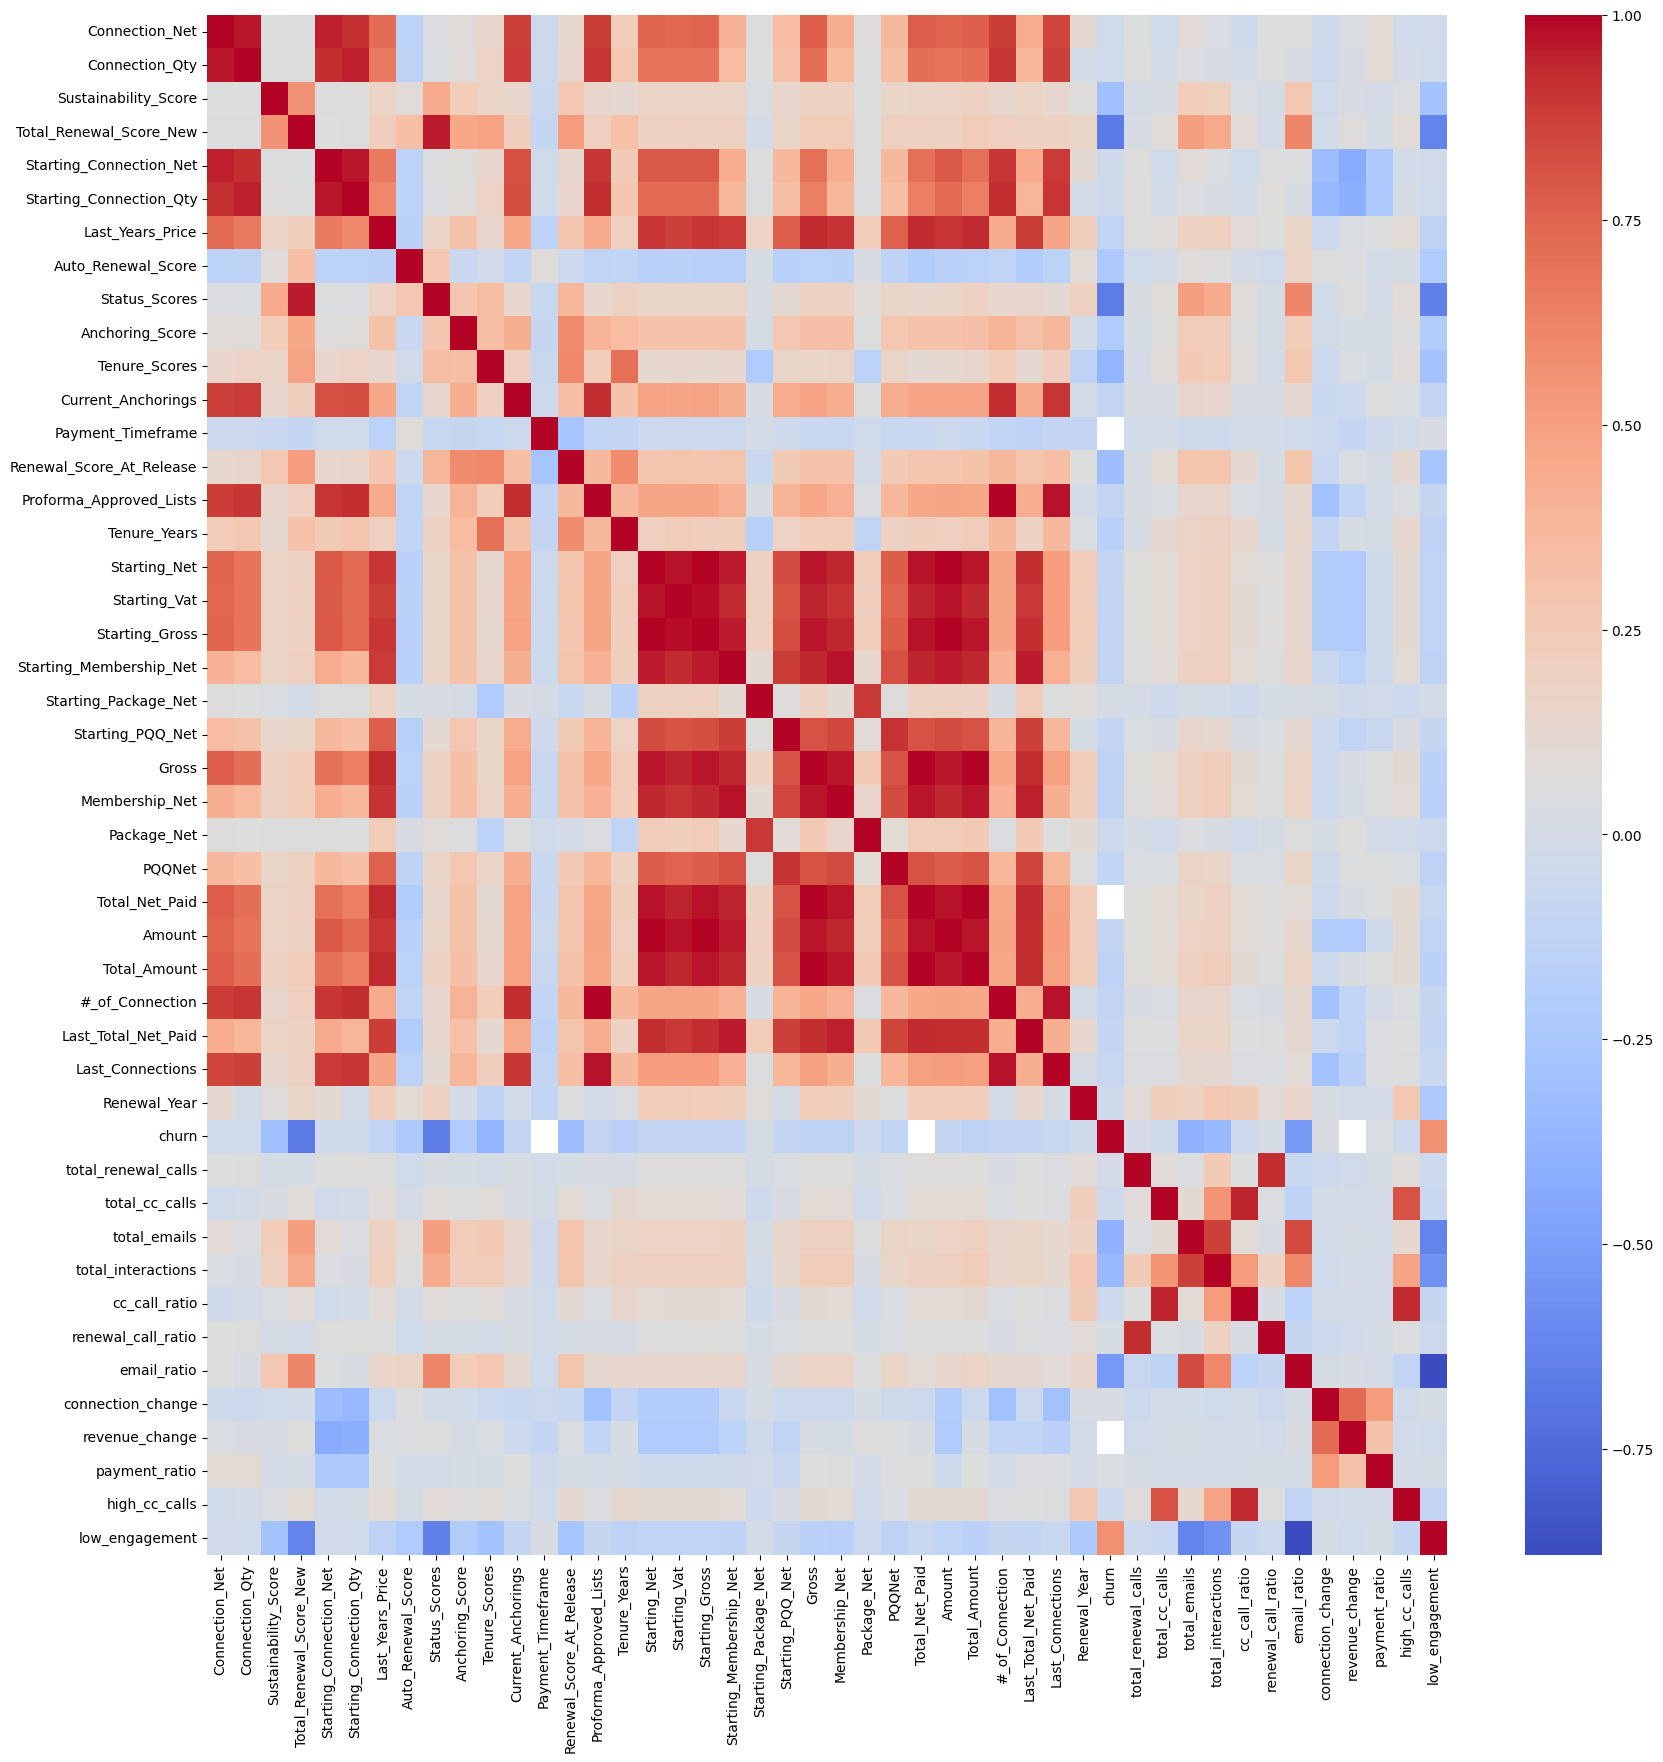

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

Insight

- Strong multicollinearity between:
  Starting_Net, Gross, Membership_Net, Total_Amount

→ These features are redundant

- Interaction features are NOT strongly correlated with others

→ They provide unique signal

8. Outlier Detection

We check extreme values in important features.


<Axes: >

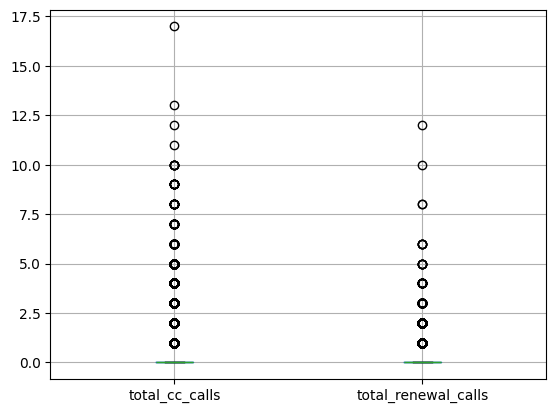

In [ ]:
df[['total_cc_calls', 'total_renewal_calls']].boxplot()

Insights

- Most customers have 0–2 calls
- Few customers have very high calls (outliers)

→ Heavy skewed distribution

In [ ]:
df.groupby('total_cc_calls')['Co_Ref'].count()

total_cc_calls
0.0     106337
1.0       4492
2.0       1717
3.0        793
4.0        314
5.0        134
6.0         44
7.0         25
8.0         16
9.0         12
10.0         6
11.0         1
12.0         1
13.0         1
17.0         1
Name: Co_Ref, dtype: int64

In [ ]:
df.groupby('total_renewal_calls')['Co_Ref'].count()

total_renewal_calls
0.0     111276
1.0       2286
2.0        238
3.0         55
4.0         24
5.0          6
6.0          5
8.0          2
10.0         1
12.0         1
Name: Co_Ref, dtype: int64

**IMPORTANT FEATURES IDENTIFIED**

STRONG FEATURES

Behavioral:
- total_interactions
- cc_call_ratio
- low_engagement
- total_emails

Customer:
- tenure_bucket
- Band
- Anchor_Group

Payment:
- Payment_Method

Time:
- Renewal_Year

WEAK FEATURES

Drop:
- High missing (>80%)
- Total_Net_Paid (leakage)
- connection_change
- revenue_change

Reduce:
- Highly correlated financial columns

Ignore:
- Raw text / date columns (unless engineered)


### STEP 8 : Hypothesis Testing + Statistical Testing

In this step, we validate whether the patterns observed during EDA are statistically significant.

We define hypotheses for key feature groups:

- Behavioral features  
- Customer profile  
- Financial features  
- Payment behavior  
- Time / lifecycle  

Statistical tests are used to determine whether observed differences are significant or occurred by chance.

Statistical Test Selection Rule

- Numerical feature vs churn → T-Test  
- Categorical feature vs churn → Chi-Square Test  

##### H1: Total Interactions vs Churn

H0: There is no difference in total interactions between churn and non-churn customers  
H1: Total interactions differ significantly between churn and non-churn customers

In [ ]:
!pip install scipy

In [ ]:
from scipy.stats import ttest_ind

group0 = df[df['churn'] == 0]['total_interactions']
group1 = df[df['churn'] == 1]['total_interactions']

t_stat, p_value = ttest_ind(group0, group1, nan_policy='omit')

print("H1 p-value:", p_value)

H1 p-value: 0.0


In [ ]:
df.groupby('churn')['total_interactions'].mean()

churn
0    1.953540
1    0.669482
Name: total_interactions, dtype: float64

##### H2: Low Engagement vs Churn

H0: Low engagement is independent of churn  
H1: Low engagement is associated with churn

In [ ]:
from scipy.stats import chi2_contingency
cont = pd.crosstab(df['low_engagement'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(cont)


print("H2 p-value:", p_value)

H2 p-value: 0.0


##### H3: Tenure vs Churn

H0: Tenure and churn are independent  
H1: Tenure is associated with churn

In [ ]:
cont = pd.crosstab(df['tenure_bucket'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(cont)

print("H3 p-value:", p_value)

H3 p-value: 0.0


##### H4: Band vs Churn

H0: Band has no relationship with churn  
H1: Band significantly impacts churn

In [ ]:
cont = pd.crosstab(df['Band'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(cont)

print("H4 p-value:", p_value)

H4 p-value: 0.0


##### H5: Payment Method vs Churn

H0: Payment method is independent of churn  
H1: Payment method significantly affects churn

In [ ]:
cont = pd.crosstab(df['Payment_Method'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(cont)

print("H5 p-value:", p_value)

H5 p-value: 0.0


In [ ]:

df[df['churn']==1]['Payment_Method'].value_counts()

Payment_Method
unknown    7832
card       4836
Name: count, dtype: int64

##### H6: Renewal Year vs Churn

H0: Churn is independent of renewal year  
H1: Churn varies across renewal years

In [ ]:
cont = pd.crosstab(df['Renewal_Year'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(cont)

print("H6 p-value:", p_value)

H6 p-value: 3.11408213068361e-44


##### H7: Email Engagement vs Churn

H0: There is no difference in email interactions between churn groups  
H1: Email interactions differ significantly between churn groups

In [ ]:
group0 = df[df['churn'] == 0]['total_emails']
group1 = df[df['churn'] == 1]['total_emails']

t_stat, p_value = ttest_ind(group0, group1, nan_policy='omit')

print("H7 p-value:", p_value)

H7 p-value: 0.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113894 entries, 0 to 113893
Data columns (total 73 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Co_Ref                      113894 non-null  str           
 1   Renewal_Month               113894 non-null  str           
 2   Connection_Net              6392 non-null    float64       
 3   Connection_Qty              6392 non-null    float64       
 4   Discount_Amount             13189 non-null   str           
 5   Sustainability_Score        113894 non-null  float64       
 6   Total_Renewal_Score_New     113894 non-null  float64       
 7   Starting_Connection_Net     6837 non-null    float64       
 8   Starting_Connection_Qty     6837 non-null    float64       
 9   Last_Years_Price            105077 non-null  float64       
 10  Auto_Renewal_Score          113894 non-null  int64         
 11  Status_Scores               113894 non-null  int64